<a href="https://colab.research.google.com/github/faiz0407/Cyberbullying-Classification/blob/main/CyberbullyingClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Utility
import numpy as np
import pandas as pd
import pickle

# Plotting
import seaborn as sns
from wordcloud import WordCloud
import matplotlib.pyplot as plt
%matplotlib inline

# nltk
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from string import punctuation

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from sklearn.metrics import classification_report

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Data Import

In [ ]:
df = pd.read_csv('cyberbullying_tweets.csv')
display(df.sample(5))
df.shape

,tweet_text,cyberbullying_type
31837,so this girl had a seizure at lunch at my high...,age
37668,When I was in high school I got bullied for my...,age
11677,"RT @ElleDunc Call me sexist, but I preferred C...",gender
44152,Fuck that nigger. damn dumb ass nigger. I hate...,ethnicity
41630,Racism is very very very deeply bred into knuc...,ethnicity


(47692, 2)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df['cyberbullying_type'].unique()

array(['not_cyberbullying', 'gender', 'religion', 'other_cyberbullying',
       'age', 'ethnicity'], dtype=object)

In [ ]:
for tweet in df.sample(5)['tweet_text']:
    print(tweet +'\n')

those tweets that say “girls that suddenly like *insert interest* bullied me in high school”, are totally right because i wouldve bullied myself for how i’m acting rn, but that’s called growth baby

@OfficPerrieE @xCharlie_mk1 i am following her-can u follow me plz, @PezzaLittleMix , @IsJesyNelson @LeighLeePinnock is followin me!!!

@Dartanveerahmad @Janx53 @geehall1 We want ISIS to remain.  It's the perfect killing place for them. Send more reinforcements.

@marshannn: “@tayyoung_: FUCK OBAMA, dumb ass nigger” FUCK YOU dumb ass whore #thisbitch seriously what an ignorant bitch. #retard

Me: they are gunna bully your daughter if she's still acts like this in high scool Mom: pobres higas de su pinche madre  no se la acaban .ha



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47692 entries, 0 to 47691
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   tweet_text          47692 non-null  object
 1   cyberbullying_type  47692 non-null  object
dtypes: object(2)
memory usage: 745.3+ KB


In [ ]:
df.describe()

,tweet_text,cyberbullying_type
count,47692,47692
unique,46017,6
top,Going to see @TheQuinnspiracy's movie I AM SO ...,religion
freq,2,7998


# Data Pre-processing

In [ ]:
df.isnull().sum()

,0
tweet_text,0
cyberbullying_type,0


In [ ]:
df['tweet_text'].duplicated().sum()

np.int64(1675)

In [ ]:
df.drop_duplicates('tweet_text', inplace=True, ignore_index=True)
df['tweet_text'].duplicated().sum()

np.int64(0)

Class *balancing*

In [ ]:
df['cyberbullying_type'].value_counts()

,count
cyberbullying_type,
religion,7995
age,7992
ethnicity,7952
not_cyberbullying,7937
gender,7898
other_cyberbullying,6243


In [ ]:
df = df[df["cyberbullying_type"] != "other_cyberbullying"]
df['cyberbullying_type'].unique()

array(['not_cyberbullying', 'gender', 'religion', 'age', 'ethnicity'],
      dtype=object)

**Label encoding the class**

In [ ]:
cyberbullying_type = ['not_cyberbullying', 'gender', 'religion', 'age', 'ethnicity']
encoding_dict = {'not_cyberbullying':0, 'gender':1, 'religion':2, 'age':3, 'ethnicity':4}
df['cyberbullying_type'] = df['cyberbullying_type'].map(encoding_dict)
df.sample(5)

,tweet_text,cyberbullying_type
31376,This is why you don't bully nerds in school - ...,3
3488,@spoonsclass Merry Christmas to all of you fro...,0
14759,@nat_com1 @Feminazi_Front We know there is a b...,1
44970,"fuck you bitch, stop posting the same shit cun...",4
35950,Nothing warms my heart more than seeing the gi...,3


# NLP Processing

Tweet cleaning and processing

In [ ]:
# Downloading dependencies
nltk.download('stopwords')  #Stopwords are common words like "the," "is," "in," "and," etc
nltk.download('punkt')      #Punkt is a pre-trained tokenizer that segments a text into words or sentences.
nltk.download('wordnet')    #WordNet is a lexical database for the English language, grouping words into sets of synonyms
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
stopwords_list = stopwords.words('english')
additional_stopwords = ['rt', 'mkr', 'didn', 'bc', 'n', 'm', 'im', 'll', 'y', 've', 'u', 'ur', 'don', 't', 's']   # Specific to twitter lingo
stopwords_list.extend(additional_stopwords)
lemmatizer = WordNetLemmatizer()

Below are the custom defined functions to deep clean the unprocessed tweets.
Their identifier names describe their working.

In [ ]:
def remove_usernames(tweet):
    words = tweet.strip().split()
    words = [word for word in words if word[0]!='@']
    return ' '.join(words)

def remove_hashtags(tweet):
    words = tweet.strip().split()
    words = [word for word in words if word[0]!='#']
    return ' '.join(words)

def remove_links(tweet):
    words = tweet.strip().split()
    words = [word for word in words if word[:4]!='http']
    return ' '.join(words)

def remove_punctuation(tweet):
    for mark in punctuation:
        tweet = tweet.replace(mark, '')
    return tweet

def convert_lowercase(tweet):
    return tweet.lower()

def tokenization(tweet):
    return word_tokenize(tweet)

def remove_stopwords(tok_tweet):
    res = []
    for word in tok_tweet:
        if word not in stopwords_list:
            res.append(word)
    return res

def lemmatize_words(tok_tweet):
    res = []
    for word in tok_tweet:
        res.append(lemmatizer.lemmatize(word))
    return res

In [ ]:
# Defining a custom tweet cleaning function
def pre_processing_custom(tweet):
    tweet = remove_usernames(tweet)
    tweet = remove_hashtags(tweet)
    tweet = remove_links(tweet)
    tweet = remove_punctuation(tweet)
    tweet = convert_lowercase(tweet)
    tok_tweet = tokenization(tweet)
    tok_tweet = remove_stopwords(tok_tweet)
    tok_tweet = lemmatize_words(tok_tweet)
    clean_tweet = ' '.join(tok_tweet)

    return clean_tweet

Time to apply this processing function to our dataset.

In [ ]:
df['clean_tweets'] = df['tweet_text'].map(pre_processing_custom)
df.sample(5)

,tweet_text,cyberbullying_type,clean_tweets
34449,"We called them ""those French bullies"" in school.",3,called french bully school
14357,ouat: this is a family show we can't have gays...,1,ouat family show cant gay also ouat let hook m...
35343,they'll never admit it but that would explain ...,3,theyll never admit would explain many people t...
3263,RT @colonelkickhead: Here is my deconstructed ...,0,deconstructed vanilla cakesome assembly required
11131,RT @Ratillathehun: @WomenDefyUKIP I`m not sex...,1,sexist thanks feminism uk mess mean harriet ha...


In [ ]:
!pip install tweet-preprocessor
import preprocessor as p

In [ ]:
def clean_tweets(tweet):
    tweet = p.clean(tweet)
    return tweet

It takes care of all the URLs, Hashtags, Mentions, Reserved Words, Emojis and Smileys.

In [ ]:
# Defining the better cleaning function
def pre_processing(tweet):
    tweet = clean_tweets(tweet)
    tweet = remove_punctuation(tweet)
    tweet = convert_lowercase(tweet)
    tok_tweet = tokenization(tweet)
    tok_tweet = remove_stopwords(tok_tweet)
    tok_tweet = lemmatize_words(tok_tweet)
    clean_tweet = ' '.join(tok_tweet)

    return clean_tweet

In [ ]:
# Clean tweets
df['clean_tweets'] = df['tweet_text'].map(pre_processing)
df.sample(5)

,tweet_text,cyberbullying_type,clean_tweets
33566,I have personally known 4 guys that became cop...,3,personally known guy became cop high school ty...
13405,If they don't mind being called females then c...,1,dont mind called female call ig woman dont lik...
30287,Perks of being a geek and a nerd we know how t...,3,perk geek nerd know talk back seduce high scho...
34203,So like i'm so sick off these girls bullying m...,3,like sick girl bullying make wish thing bully ...
21417,@harmlesstree2 The holocaust happened in India...,2,holocaust happened india muslim scum murdered ...


Checking again if any values got duplicated.

In [ ]:
df['clean_tweets'].duplicated().sum()

np.int64(1215)

Removing them all.

In [ ]:
df.drop_duplicates('clean_tweets', inplace=True, ignore_index=True)
df['clean_tweets'].duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(38559, 3)

Now that we have processed the tweets, it's time to move forward and calculate the total and average word lengths of each tweet.

In [ ]:
# Total word count of a tweet
df['word_count'] = df['tweet_text'].map(lambda x: len(x.split()))
df.sample(5)

,tweet_text,cyberbullying_type,clean_tweets,word_count
15004,How in the hell did you get on my page you pei...,1,hell get page peice lying crap call bitch lil ...,37
7480,How can you be getting bullied into doing shif...,0,getting bullied shift life joke,15
31677,Dumb ugly fuck name wayne ugly nigger off my p...,4,dumb ugly fuck name wayne ugly nigger phone mo...,19
31933,Um hey truth as a black man in a company that ...,4,um hey truth black man company past incident r...,25
3374,@Jason_Gio he was already given my email a whi...,0,already given email ago someone else,13


In [ ]:
# Average word length of a tweet
def avg_word_length(tweet):
    words = tweet.split()
    word_count = len(words)
    word_length = 0
    for word in words:
        word_length += len(word)
    avg_length = round(word_length / word_count,2)
    return avg_length

df['avg_word_length'] = df['tweet_text'].map(avg_word_length)
df.sample(5)

,tweet_text,cyberbullying_type,clean_tweets,word_count,avg_word_length
37516,"I totally agree that human history is vile, an...",4,totally agree human history vile something lea...,41,4.88
37946,Swear these niggers some dumb fucks,4,swear nigger dumb fuck,6,5.00
20635,@CamilleHughes16 @_Watch_Observe_ That's like ...,2,thats like saying freedom limited allowed kill,17,5.59
14105,Hope one of those bitches falls over and break...,1,hope one bitch fall break leg,12,4.08
208,"Bullying linked to decreases in GPA, longer la...",0,bullying linked decrease gpa longer lasting ne...,16,7.38


We can also remove the outliers and the tweets useless to us from this dataset, like this

In [ ]:
df = df[df['word_count']>3]
df = df[df['word_count']<100]
df.reset_index(drop=True, inplace=True)
df.shape

(38202, 5)

# Data Visualization

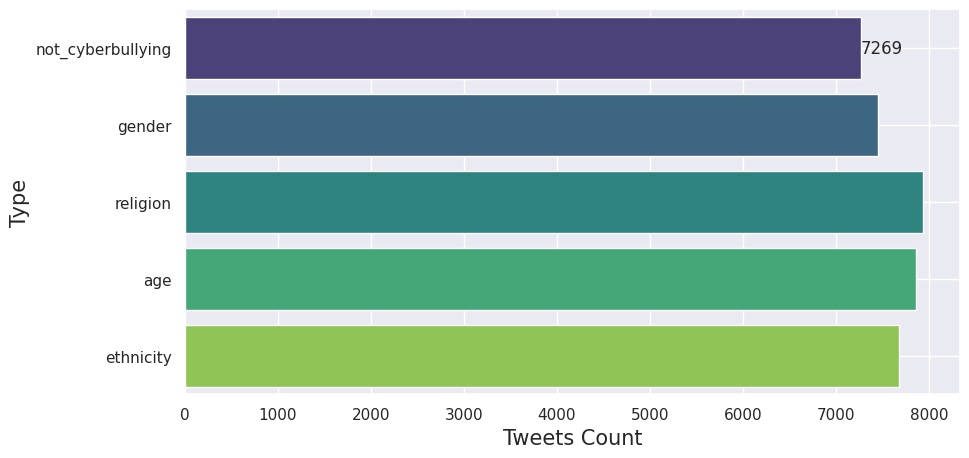

In [ ]:
sns.set_theme()
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, y='cyberbullying_type', palette="viridis")
ax.bar_label(ax.containers[0])
plt.yticks(ticks=[0,1,2,3,4], labels=cyberbullying_type)
plt.xlabel('Tweets Count', size=15)
plt.ylabel('Type', size=15)
plt.grid(color='w')

All the classes look balanced.

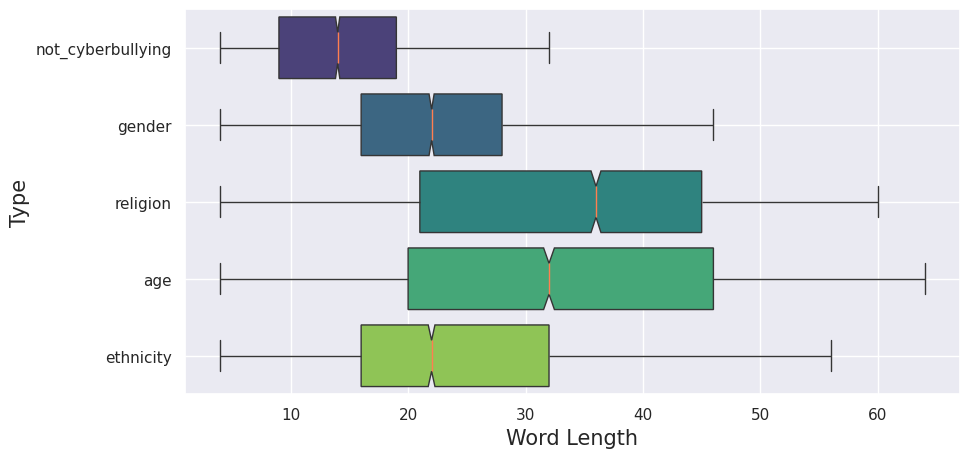

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, y='cyberbullying_type', x='word_count', orient='h', showfliers=False, palette='viridis', notch=True, medianprops={"color": "coral"})
plt.yticks(ticks=[0,1,2,3,4], labels=cyberbullying_type)
plt.xlabel('Word Length', size=15)
plt.ylabel('Type', size=15)
plt.grid(color='w')

We can observe that the tweets targeted towards a gender tend to have a bit less words in them than say, the ones targeted towards religion.
But overall, a bullying tweet has more words in it and is more varied than a normal one.

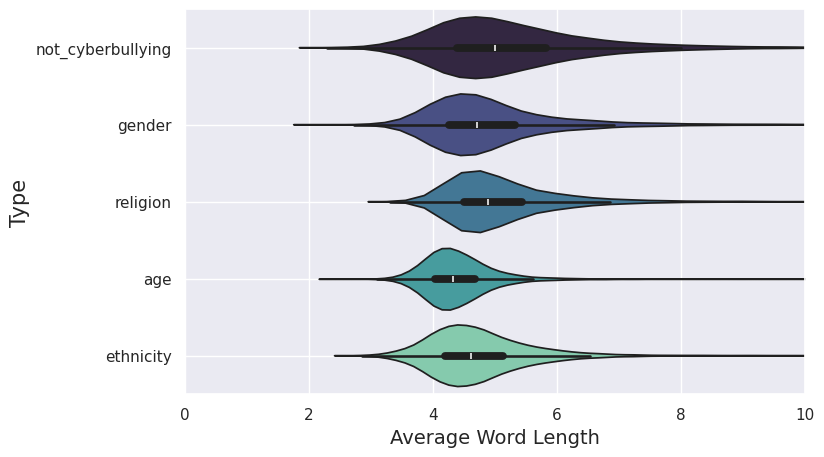

In [ ]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, y='cyberbullying_type', x='avg_word_length', orient='h', palette='mako')
plt.xlim(0, 10)
plt.yticks(ticks=[0,1,2,3,4], labels=cyberbullying_type)
plt.xlabel('Average Word Length', size=14)
plt.ylabel('Type', size=15)
plt.grid(color='w')

Pretty much the same for all, between 4 to 6 letters.

Text(32.0, 0.5, 'Average Word Length')

<Figure size 800x500 with 0 Axes>

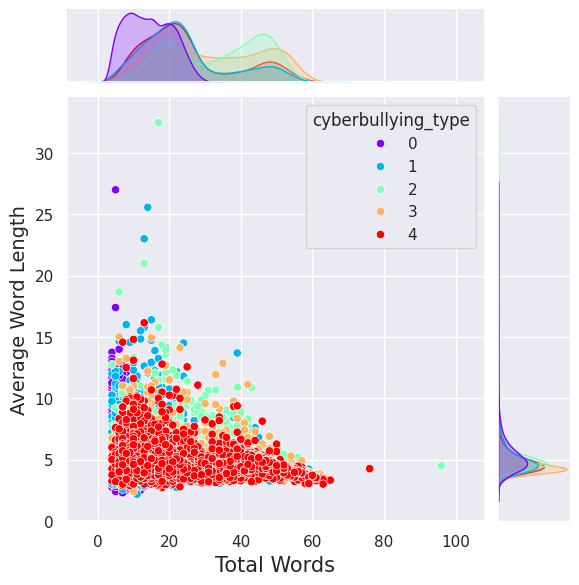

In [ ]:
plt.figure(figsize=(8, 5))
sns.jointplot(data=df, y='avg_word_length', x='word_count', hue='cyberbullying_type', palette='rainbow')
plt.xlabel('Total Words', size=15)
plt.ylabel('Average Word Length', size=14)

**Word Clouds**

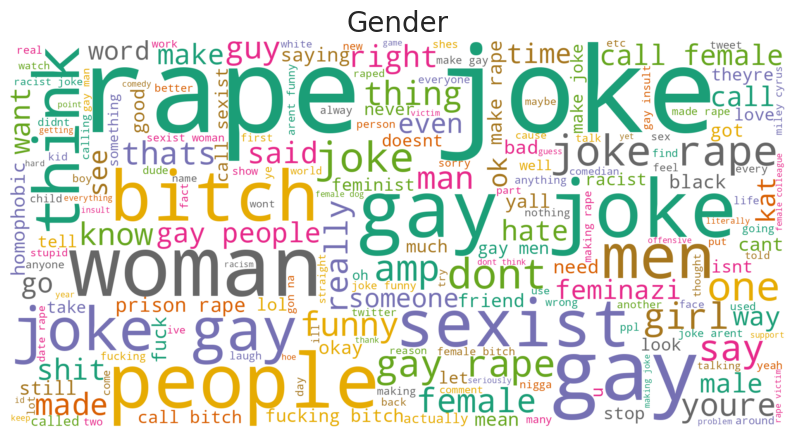

In [ ]:
# Gender
plt.figure(figsize=(10, 10))
subset1 = df[df['cyberbullying_type']==1]
text_gender = subset1['clean_tweets'].values
wc1 = WordCloud(background_color='white', colormap='Dark2', width=2000, height=1000).generate(' '.join(text_gender))

plt.axis('off')
plt.title("Gender", fontsize=20)
plt.imshow(wc1, interpolation='bilinear')

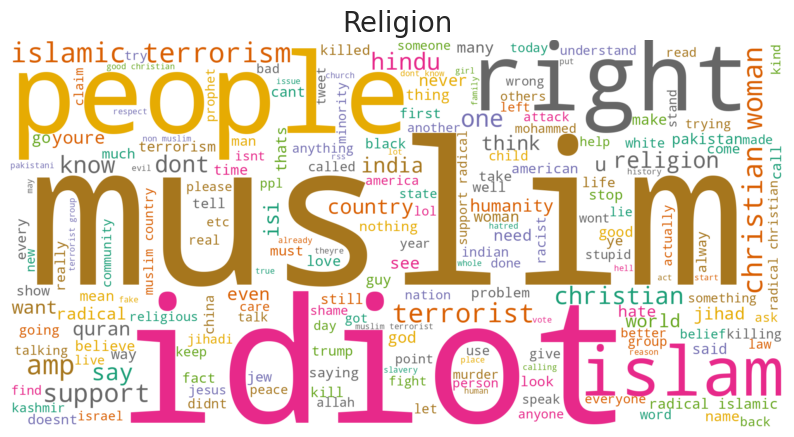

In [ ]:
# Religion
plt.figure(figsize=(10, 10))
subset2 = df[df['cyberbullying_type']==2]
text_religion = subset2['clean_tweets'].values
wc2 = WordCloud(background_color='white', colormap='Dark2', width=2000, height=1000).generate(' '.join(text_religion))

plt.axis('off')
plt.title("Religion", fontsize=20)
plt.imshow(wc2, interpolation='bilinear')

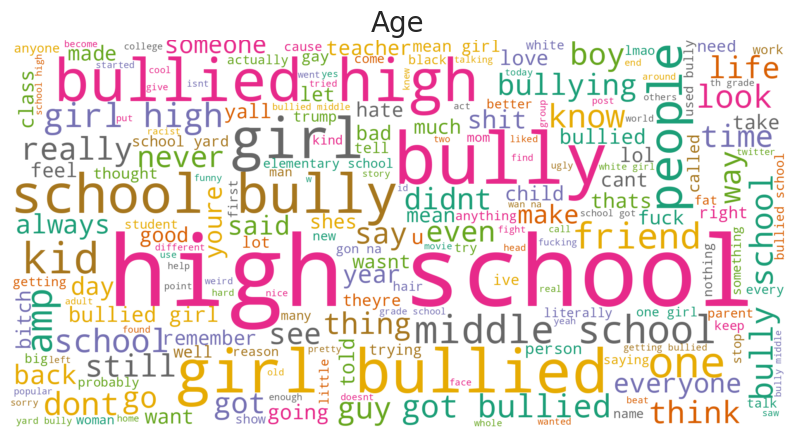

In [ ]:
# Age
plt.figure(figsize=(10, 10))
subset3 = df[df['cyberbullying_type']==3]
text_age = subset3['clean_tweets'].values
wc3 = WordCloud(background_color='white', colormap='Dark2', width=2000, height=1000).generate(' '.join(text_age))

plt.axis('off')
plt.title("Age", fontsize=20)
plt.imshow(wc3, interpolation='bilinear')


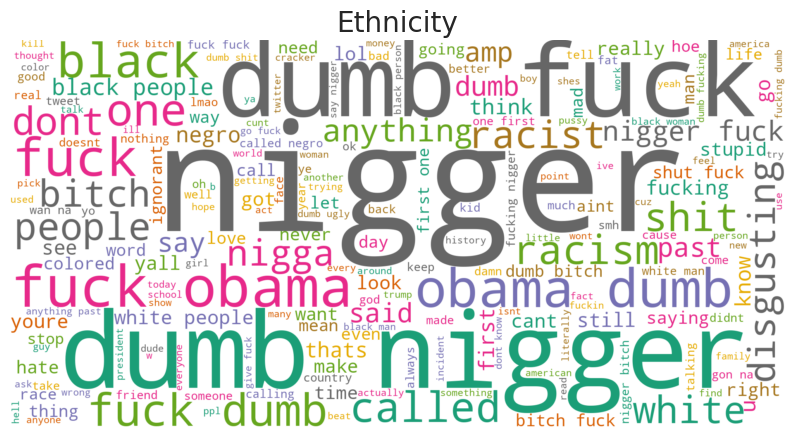

In [ ]:
# Ethnicity
plt.figure(figsize=(10, 10))
subset4 = df[df['cyberbullying_type']==4]
text_ethnicity = subset4['clean_tweets'].values
wc4 = WordCloud(background_color='white', colormap='Dark2', width=2000, height=1000).generate(' '.join(text_ethnicity))

plt.axis('off')
plt.title("Ethnicity", fontsize=20)
plt.imshow(wc4, interpolation='bilinear')

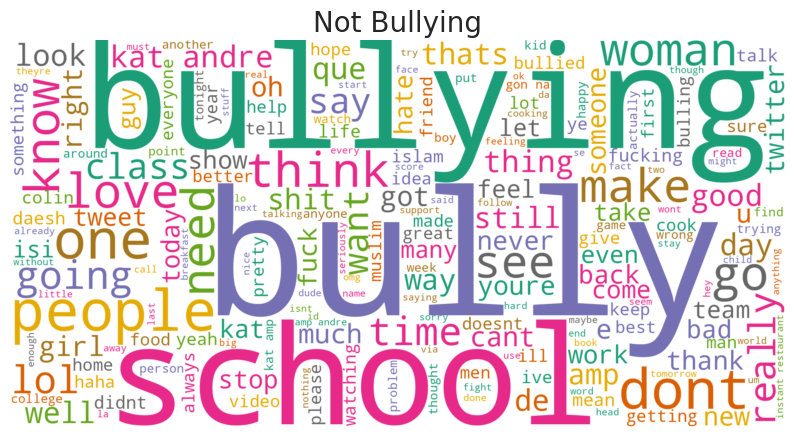

In [ ]:
# Not Bullying
plt.figure(figsize=(10, 10))
subset0 = df[df['cyberbullying_type']==0]
text_not = subset0['clean_tweets'].values
wc0 = WordCloud(background_color='white', colormap='Dark2', width=2000, height=1000).generate(' '.join(text_not))

plt.axis('off')
plt.title("Not Bullying", fontsize=20)
plt.imshow(wc0, interpolation='bilinear')

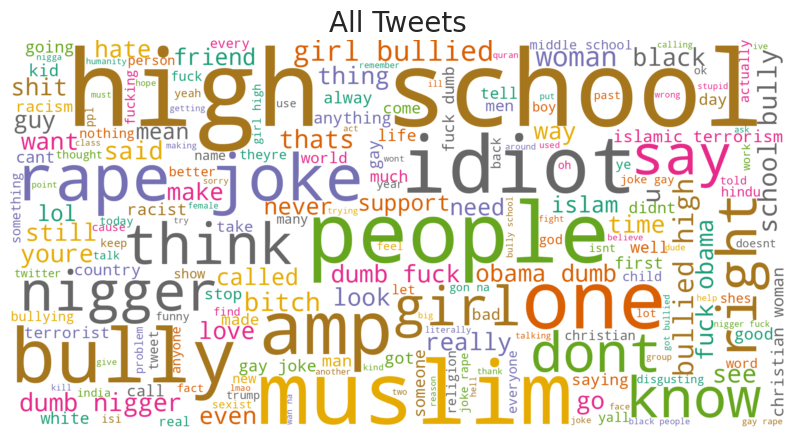

In [ ]:
# All Tweets
plt.figure(figsize=(10, 10))
text_all = df['clean_tweets'].values
wc = WordCloud(background_color='white', colormap='Dark2', width=2000, height=1000).generate(' '.join(text_all))

plt.axis('off')
plt.title("All Tweets", fontsize=20)
plt.imshow(wc, interpolation='bilinear')

Now that we're done with the wordclouds, let's check which words are the most popular.

In [ ]:
from collections import Counter   # To count the frequency of each word

temp=[]
for tweet in df['clean_tweets']:
  for word in tweet.split():
    temp.append(word)
vocab = Counter(temp)
print("Vocabulary Size:", len(vocab))
print(list(vocab.items())[:5])

Vocabulary Size: 38477
[('word', 867), ('food', 128), ('crapilicious', 1), ('white', 2213), ('classy', 29)]


vocab contains the frequency of all the unique words in the whole dataset. Pretty interesting.
Let's try to plot it and see what we get.

In [ ]:
common_word=[]
freq=[]
for i, j in vocab.most_common()[:10]:
  common_word.append(i)
  freq.append(j)

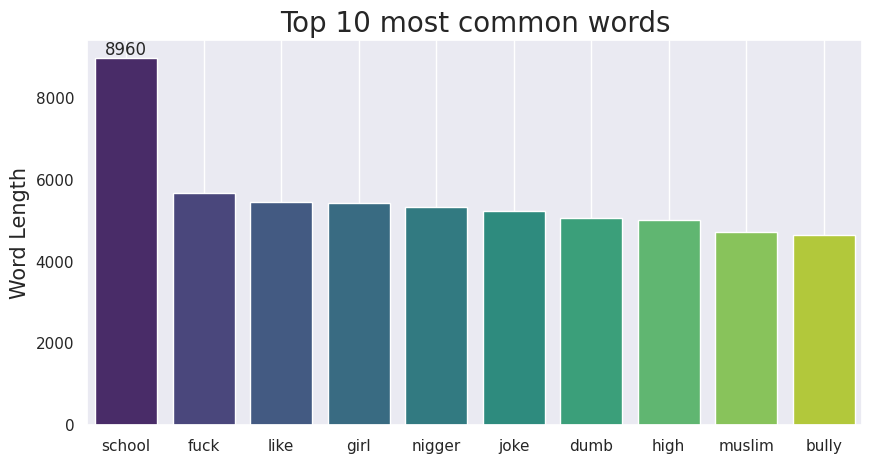

In [ ]:
# Most common words
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=common_word, y=freq, palette='viridis')
plt.title('Top 10 most common words', size=20)
ax.bar_label(ax.containers[0])
plt.ylabel("Word Length", size=15)
plt.grid()

# ML Classifiers

Now that we have analyzed and visualized the dataset, had some reality check after seeing the wordclouds, its time to get our hands dirty and apply various ML classifiers to it, and see which one performs the best.

First, we start by splitting the data into train and test.



In [ ]:
X = df['clean_tweets']
y = df['cyberbullying_type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=76)

**TF-IDF Vectorization**

In [ ]:
tfidf = TfidfVectorizer(ngram_range=(1,2))
tfidf.fit(X_train)    # Fit on train
print("No. of feature words:", len(tfidf.get_feature_names_out()))

No. of feature words: 291954


In [ ]:
X_train_tf = tfidf.transform(X_train)
X_test_tf = tfidf.transform(X_test)
print(f"{X_train_tf.shape = }\n{X_test_tf.shape = }")

X_train_tf.shape = (30561, 291954)
X_test_tf.shape = (7641, 291954)


**Logistic Regression**

In [ ]:
# Model training
lr = LogisticRegression(solver='saga', penalty='l2', random_state=394)
lr.fit(X_train_tf, y_train)

LogisticRegression(random_state=394, solver='saga')

In [ ]:
# Model prediction
y_pred_train = lr.predict(X_train_tf)
y_pred_test = lr.predict(X_test_tf)

In [ ]:
# Model evaluation
print('\tClassification Report for Logistic Regression on Train\n\n', classification_report(y_train, y_pred_train, target_names=cyberbullying_type))
print('\n\tClassification Report for Logistic Regression on Test\n\n', classification_report(y_test, y_pred_test, target_names=cyberbullying_type))

	Classification Report for Logistic Regression on Train

                    precision    recall  f1-score   support

not_cyberbullying       0.88      0.95      0.91      5815
           gender       0.98      0.91      0.94      5958
         religion       0.98      0.98      0.98      6350
              age       0.98      0.99      0.98      6292
        ethnicity       0.99      0.99      0.99      6146

         accuracy                           0.96     30561
        macro avg       0.96      0.96      0.96     30561
     weighted avg       0.96      0.96      0.96     30561


	Classification Report for Logistic Regression on Test

                    precision    recall  f1-score   support

not_cyberbullying       0.80      0.79      0.80      1454
           gender       0.93      0.85      0.89      1490
         religion       0.95      0.95      0.95      1587
              age       0.92      0.99      0.95      1573
        ethnicity       0.96      0.99      0.97      

The performance score of the algorithm is very good, with an overall accurcy of 92%.
We can observe how the predictions for the classes have very high F1 scores, while for the class "non-cyberbullying" the score is much lower.

Text(0.5, 1.0, 'Confusion Matrix LR')

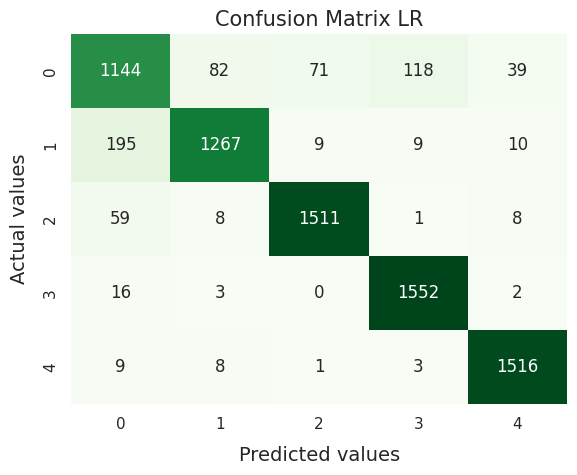

In [ ]:
# Confusion Matrix for Logistic Regression
sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, cmap="Greens", fmt='', cbar=False)
plt.xlabel("Predicted values", fontdict = {'size':14}, labelpad = 10)
plt.ylabel("Actual values", fontdict = {'size':14}, labelpad = 10)
plt.title('Confusion Matrix LR', size=15)

**Random Forest**

In [ ]:
# Model training
rf = RandomForestClassifier(n_estimators=100, criterion="entropy", max_depth=30, random_state=27)
rf.fit(X_train_tf, y_train)

RandomForestClassifier(criterion='entropy', max_depth=30, random_state=27)

In [ ]:
# Model prediction
y_pred_train = rf.predict(X_train_tf)
y_pred_test = rf.predict(X_test_tf)

In [ ]:
# Model evaluation
print('\tClassification Report for Random Forest on Train\n\n', classification_report(y_train, y_pred_train, target_names=cyberbullying_type))
print('\n\tClassification Report for Random Forest on Test\n\n', classification_report(y_test, y_pred_test, target_names=cyberbullying_type))

	Classification Report for Random Forest on Train

                    precision    recall  f1-score   support

not_cyberbullying       0.76      0.92      0.84      5815
           gender       0.98      0.77      0.86      5958
         religion       0.96      0.96      0.96      6350
              age       0.97      0.98      0.97      6292
        ethnicity       0.98      0.98      0.98      6146

         accuracy                           0.92     30561
        macro avg       0.93      0.92      0.92     30561
     weighted avg       0.93      0.92      0.92     30561


	Classification Report for Random Forest on Test

                    precision    recall  f1-score   support

not_cyberbullying       0.74      0.88      0.81      1454
           gender       0.97      0.76      0.85      1490
         religion       0.95      0.94      0.94      1587
              age       0.95      0.97      0.96      1573
        ethnicity       0.96      0.97      0.97      1537

      

Text(0.5, 1.0, 'Confusion Matrix RF')

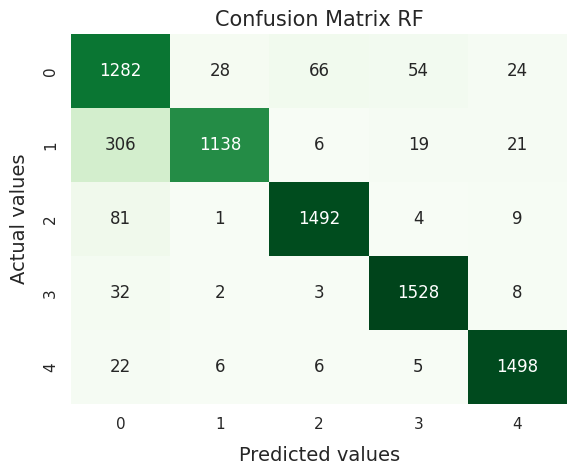

In [ ]:
# Confusion Matrix for Random Forest
sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, cmap="Greens", fmt='', cbar=False)
plt.xlabel("Predicted values", fontdict = {'size':14}, labelpad = 10)
plt.ylabel("Actual values", fontdict = {'size':14}, labelpad = 10)
plt.title('Confusion Matrix RF', size=15)

**XGBoost**

In [ ]:
# Convert sparse matrix to dense if necessary (for XGBoost)
X_train_dense = X_train_tf.toarray()
X_test_dense = X_test_tf.toarray()

In [ ]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train_dense, y_train)

In [ ]:
# Predict and evaluate the model
y_pred = xgb_model.predict(X_test_dense)

# Generate classification report
print(classification_report(y_test, y_pred))

In [ ]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, cmap="Greens", fmt='g', cbar=False)  # Use 'g' for integer format
plt.xlabel("Predicted values", fontdict={'size': 14}, labelpad=10)
plt.ylabel("Actual values", fontdict={'size': 14}, labelpad=10)
plt.title('Confusion Matrix for XGBoost', size=15)
plt.show()

**Model Saving, Loading and Prediction**

In [ ]:
model_file = open('LogisticRegression.pickle','wb')
pickle.dump(lr, model_file)
model_file.close()

model_file = open('RandomForest.pickle','wb')
pickle.dump(rf, model_file)
model_file.close()

model_file = open('XGBoost.pickle', 'wb')
pickle.dump(xgb_model, model_file)
model_file.close()

In [ ]:
# Defining our custom prediction function
def predict(model, texts):
    clean_texts = [pre_processing_custom(text) for text in texts]
    text_data = tfidf.transform(clean_texts)
    prediction = model.predict(text_data)

    data = []
    for text, prediction in zip(texts, prediction):
        data.append((text, prediction))

    df = pd.DataFrame(data, columns = ['text','type'])
    df = df.replace([0,1,2,3,4], cyberbullying_type)
    return df

In [ ]:
model_file = open('XGBoost.pickle', 'wb')
pickle.dump(xgb_model, model_file)
model_file.close()

In [ ]:
texts = ["hey! i m planning to go to a trip to hills."]

predict(model, texts)

,text,type
0,hey! i m planning to go to a trip to hills.,not_cyberbullying
